In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load DataSet

In [2]:
df = pd.read_csv('AAPL.csv')
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.head()

,Open,High,Low,Close,Volume
0,0.128348,0.128906,0.128348,0.128348,469033600
1,0.122210,0.122210,0.121652,0.121652,175884800
2,0.113281,0.113281,0.112723,0.112723,105728000
3,0.115513,0.116071,0.115513,0.115513,86441600
4,0.118862,0.119420,0.118862,0.118862,73449600


### EDA

In [3]:
df.shape

(10468, 5)

In [4]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

### Train Test Split

In [6]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=False)

### Standard Scaler

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [8]:
x_train_scaled = scaler.fit_transform(df_train)
x_test_scaled = scaler.transform(df_test)

### Create Sequences

In [9]:
def create_data(data):

    x = []
    y = []

    for i in range(60, len(data)):

        # Previous 60 Days
        x.append(data[i - 60: i])

        # Next Days Close
        y.append(data[i, 3])
    return np.array(x), np.array(y)

x_train, y_train = create_data(x_train_scaled)
x_test, y_test = create_data(x_test_scaled)

## Transformer Archeticture

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential, Model
from keras.layers import Input, Embedding, MultiHeadAttention, LayerNormalization, Dense

## Encoder Archeticture

### Multi-Head Attention

In [11]:
encoder_inputs = Input(shape=(60, 5))
encoder_attention = MultiHeadAttention(num_heads=4, key_dim=32)(encoder_inputs, encoder_inputs)

### Adds & Norm

In [12]:
encoder_add = encoder_inputs + encoder_attention
encoder_norm = LayerNormalization()(encoder_add)

## FFN

In [13]:
encoder_ffn = Dense(128, activation='relu')(encoder_norm)

### Output Layer

In [14]:
encoder_output = Dense(5)(encoder_ffn)

## Decoder Archeticture

In [35]:
decoder_inputs = Input(shape=(60, 5))
decoder_attention = MultiHeadAttention(num_heads=4, key_dim=32)(decoder_inputs, decoder_inputs, use_causal_mask=True)

### Add & Norm

In [36]:
decoder_add = decoder_inputs + decoder_attention
decoder_norm = LayerNormalization()(decoder_add)

### Cross Attention

In [37]:
cross_attention = MultiHeadAttention(num_heads=4, key_dim=32)(decoder_norm, encoder_output)

### Add & Norm

In [38]:
decoder_add2 = cross_attention + decoder_norm
decoder_norm2 = LayerNormalization()(decoder_add2)

## FFN

In [39]:
decoder_ffn = Dense(256, activation='relu')(decoder_norm2)
decoder_output = Dense(5)(decoder_ffn)

### Output Layer

In [40]:
last_output = decoder_output[:, -1, :]
output = Dense(1)(last_output)

### Complete Model

In [41]:
model = Model(
    [encoder_inputs, decoder_inputs],
    output
)

### Model Compilation

In [42]:
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.R2Score(name='r2_score')])

### Model Training

In [43]:
history = model.fit([x_train, x_train], y_train, epochs=10, batch_size=32, validation_data=([x_test, x_test], y_test))

Epoch 1/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - loss: 0.0063 - r2_score: 0.8527 - val_loss: 5.5555 - val_r2_score: -0.6741
Epoch 2/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 4.1217e-04 - r2_score: 0.9904 - val_loss: 5.5051 - val_r2_score: -0.6589
Epoch 3/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step - loss: 3.9865e-04 - r2_score: 0.9904 - val_loss: 5.3997 - val_r2_score: -0.6271
Epoch 4/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 53s 140ms/step - loss: 4.0115e-04 - r2_score: 0.9904 - val_loss: 5.3312 - val_r2_score: -0.6065
Epoch 5/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 2.3541e-04 - r2_score: 0.9943 - val_loss: 5.2975 - val_r2_score: -0.5963
Epoch 6/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - loss: 5.8537e-04 - r2_score: 0.9860 - val_loss: 5.1868 - val_r2_score: -0.5630
Epoch 7/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - loss: 2.6494e-04 - r2_score: 0.9939 - val_loss: 5.2943 - val_r2_score: -0.5954
Epoch 8/10
260/260 ━━━━━━━━━━━━━━━━━━━━ 37s 141ms/step - l

### R2 Score

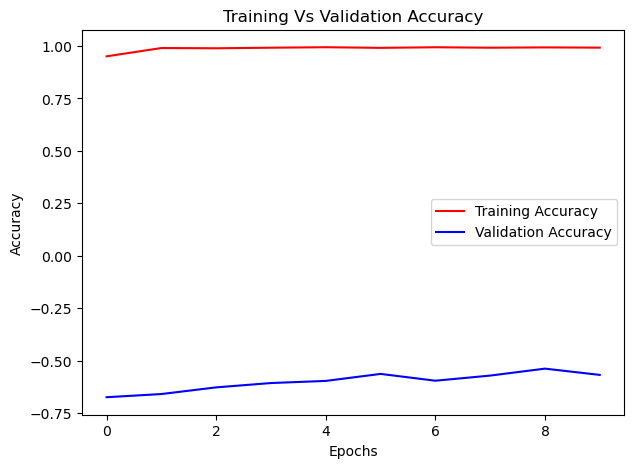

In [49]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['r2_score'], label='Training Accuracy', color='red')
plt.plot(history.history['val_r2_score'], label='Validation Accuracy', color='blue')
plt.title("Training Vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Loss

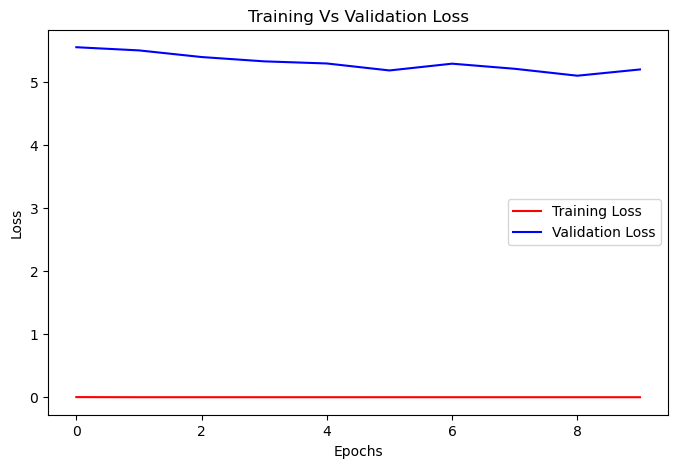

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title("Training Vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()